**PIMA DATASET**

✅ Dataset loaded: (768, 9)
✅ After SMOTEENN: (596, 8)
Class distribution after balancing:
Outcome
1    321
0    275
Name: count, dtype: int64
✅ Base models trained
✅ Meta-train shape: (476, 4)
✅ Meta-test shape: (120, 4)
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.3388 - loss: 0.8521 - val_accuracy: 0.5208 - val_loss: 0.8263
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4087 - loss: 0.7836 - val_accuracy: 0.7812 - val_loss: 0.7436
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6574 - loss: 0.7102 - val_accuracy: 0.8438 - val_loss: 0.6574
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8067 - loss: 0.6703 - val_accuracy: 0.8854 - val_loss: 0.6030
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8573 - loss: 0.5785 - val_accuracy: 0.8958 - val_loss: 0.5533
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8910 - loss: 0.5514 - val_accuracy: 0.9062 - val_loss: 0.5133
Epoch 7/20
24/24 ━━━━━

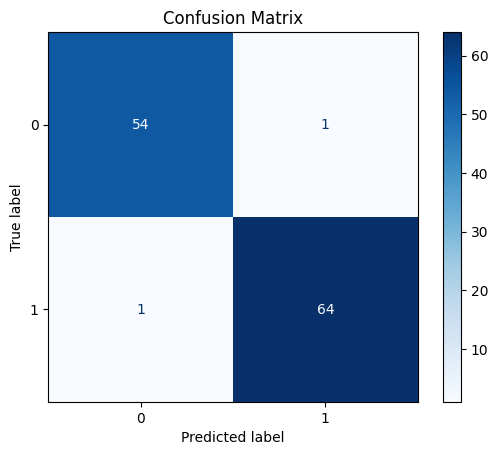

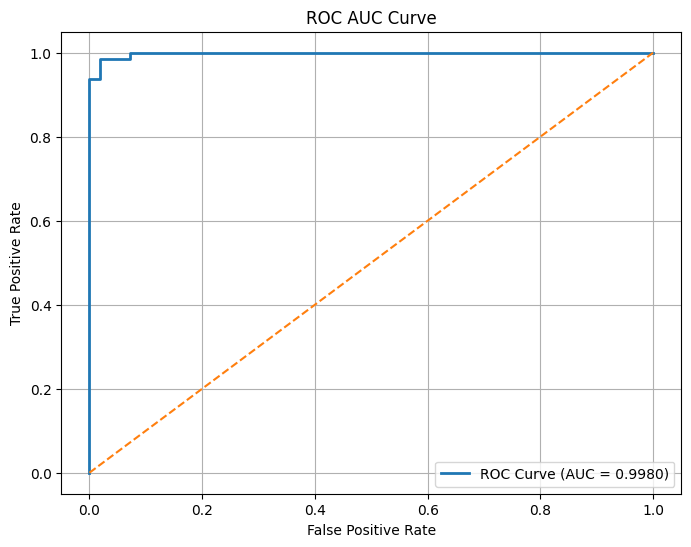

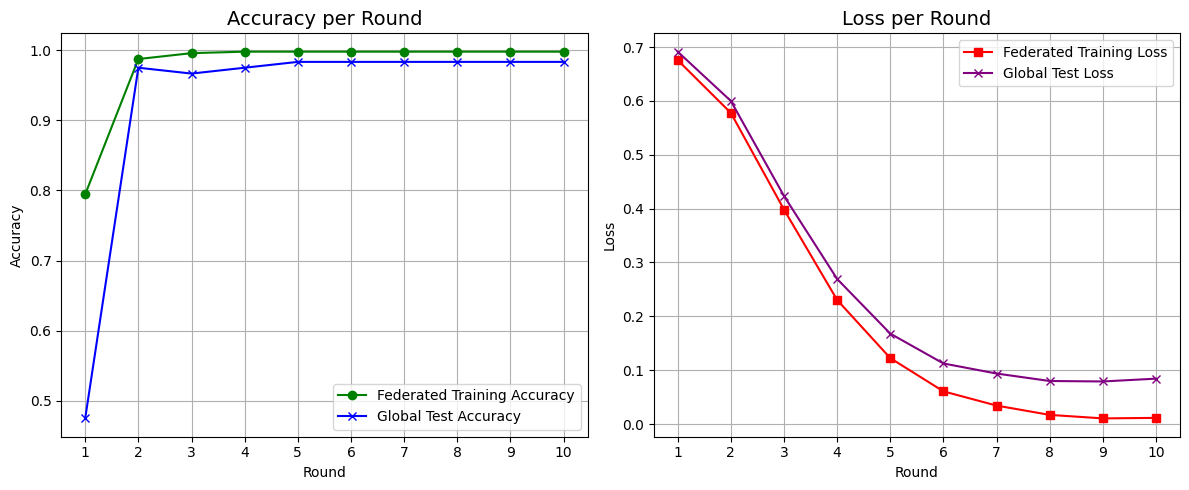

In [7]:
# ==========================================
# KAGGLE-COMPATIBLE UPDATED ONE-CELL CODE
# FOR YOUR SECOND TFF-BASED PIPELINE
# ==========================================

# !pip install -q xgboost imbalanced-learn seaborn

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
)

# ============================
# 1. LOAD DATASET
# ============================
DATA_PATH = "/kaggle/input/datasets/aqsaaries/pima-diabetese/pima-diabetes.csv"   # <-- update if needed

if not os.path.exists(DATA_PATH):
    print("⚠️ DATA_PATH not found. Available files under /kaggle/input:\n")
    shown = 0
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            print(os.path.join(root, f))
            shown += 1
            if shown >= 30:
                break
        if shown >= 30:
            break
    raise FileNotFoundError("Please update DATA_PATH to the correct Kaggle dataset path.")

data = pd.read_csv(DATA_PATH)
print("✅ Dataset loaded:", data.shape)

target_column = "Outcome"
X = data.drop(columns=[target_column])
y = data[target_column]

# ============================
# 2. STANDARDIZE FEATURES
# ============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================
# 3. APPLY SMOTEENN
# ============================
smoteenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smoteenn.fit_resample(X_scaled, y)

print("✅ After SMOTEENN:", X_resampled.shape)
print("Class distribution after balancing:")
print(pd.Series(y_resampled).value_counts())

# ============================
# 4. TRAIN-TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

# ============================
# 5. TRAIN BASE MODELS
# ============================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric="logloss", random_state=42)
svm = CalibratedClassifierCV(SVC(kernel="rbf", probability=True, random_state=42))
knn = CalibratedClassifierCV(KNeighborsClassifier(n_neighbors=5))

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

print("✅ Base models trained")

# ============================
# 6. CREATE META-FEATURES
# ============================
meta_train = np.column_stack([
    rf.predict_proba(X_train)[:, 1],
    xgb.predict_proba(X_train)[:, 1],
    svm.predict_proba(X_train)[:, 1],
    knn.predict_proba(X_train)[:, 1]
]).astype(np.float32)

meta_test = np.column_stack([
    rf.predict_proba(X_test)[:, 1],
    xgb.predict_proba(X_test)[:, 1],
    svm.predict_proba(X_test)[:, 1],
    knn.predict_proba(X_test)[:, 1]
]).astype(np.float32)

y_train_array = np.array(y_train).astype(np.float32)
y_test_array = np.array(y_test).astype(np.float32)

print("✅ Meta-train shape:", meta_train.shape)
print("✅ Meta-test shape:", meta_test.shape)

# ============================
# 7. PRE-TRAIN META MODEL
# ============================
meta_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(8, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

meta_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

meta_model.fit(
    meta_train,
    y_train_array,
    epochs=20,
    batch_size=16,
    verbose=1,
    validation_split=0.2,
    callbacks=[early_stopping]
)

print("✅ Meta model pre-training completed")

# ============================
# 8. MANUAL FEDERATED LEARNING (FedAvg)
# ============================
NUM_CLIENTS = 5
NUM_ROUNDS = 10
LOCAL_EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 0.01

# Split meta-train data into clients
X_parts = np.array_split(meta_train, NUM_CLIENTS)
y_parts = np.array_split(y_train_array, NUM_CLIENTS)

def create_federated_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def average_weights(weight_list):
    avg_weights = []
    for weights in zip(*weight_list):
        avg_weights.append(np.mean(weights, axis=0))
    return avg_weights

global_model = create_federated_model()
global_weights = global_model.get_weights()

round_accuracy = []
round_loss = []
global_test_accuracy = []
global_test_loss = []

print("\n🚀 Starting Manual Federated Training...\n")

for round_num in range(NUM_ROUNDS):
    local_weights = []
    local_accuracies = []
    local_losses = []

    for client_id in range(NUM_CLIENTS):
        client_model = create_federated_model()
        client_model.set_weights(global_weights)

        client_model.fit(
            X_parts[client_id],
            y_parts[client_id],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        loss, acc = client_model.evaluate(X_parts[client_id], y_parts[client_id], verbose=0)
        local_losses.append(loss)
        local_accuracies.append(acc)
        local_weights.append(client_model.get_weights())

    # FedAvg aggregation
    global_weights = average_weights(local_weights)
    global_model.set_weights(global_weights)

    avg_acc = float(np.mean(local_accuracies))
    avg_loss = float(np.mean(local_losses))
    round_accuracy.append(avg_acc)
    round_loss.append(avg_loss)

    g_loss, g_acc = global_model.evaluate(meta_test, y_test_array, verbose=0)
    global_test_accuracy.append(float(g_acc))
    global_test_loss.append(float(g_loss))

    print(
        f"Round {round_num+1:02d}/{NUM_ROUNDS} | "
        f"Federated Training Accuracy: {avg_acc:.4f} | "
        f"Federated Training Loss: {avg_loss:.4f} | "
        f"Global Test Accuracy: {g_acc:.4f} | "
        f"Global Test Loss: {g_loss:.4f}"
    )

print("\n✅ Federated training completed")

# ============================
# 9. FINAL EVALUATION
# ============================
final_model = create_federated_model()
final_model.set_weights(global_weights)

loss, accuracy = final_model.evaluate(meta_test, y_test_array, verbose=0)
print(f"\n✅ Final Federated Model Test Accuracy: {accuracy:.4f}")
print(f"✅ Final Federated Model Test Loss: {loss:.4f}")

# ============================
# 10. PREDICTIONS AND METRICS
# ============================
y_pred_proba = final_model.predict(meta_test, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

precision = precision_score(y_test_array, y_pred)
recall = recall_score(y_test_array, y_pred)
f1 = f1_score(y_test_array, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy_score(y_test_array, y_pred):.4f}")

# ============================
# 11. CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_test_array, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ============================
# 12. ROC CURVE
# ============================
fpr, tpr, thresholds = roc_curve(y_test_array, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ============================
# 13. FEDERATED ACCURACY & LOSS CURVES
# ============================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_ROUNDS+1), round_accuracy, marker="o", color="green", label="Federated Training Accuracy")
plt.plot(range(1, NUM_ROUNDS+1), global_test_accuracy, marker="x", color="blue", label="Global Test Accuracy")
plt.title("Accuracy per Round", fontsize=14)
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.xticks(range(1, NUM_ROUNDS+1))
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_ROUNDS+1), round_loss, marker="s", color="red", label="Federated Training Loss")
plt.plot(range(1, NUM_ROUNDS+1), global_test_loss, marker="x", color="purple", label="Global Test Loss")
plt.title("Loss per Round", fontsize=14)
plt.xlabel("Round")
plt.ylabel("Loss")
plt.xticks(range(1, NUM_ROUNDS+1))
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Stacking Model Performance:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        62
           1       1.00      0.97      0.98        58

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120

Stacking Model Accuracy: 0.9833


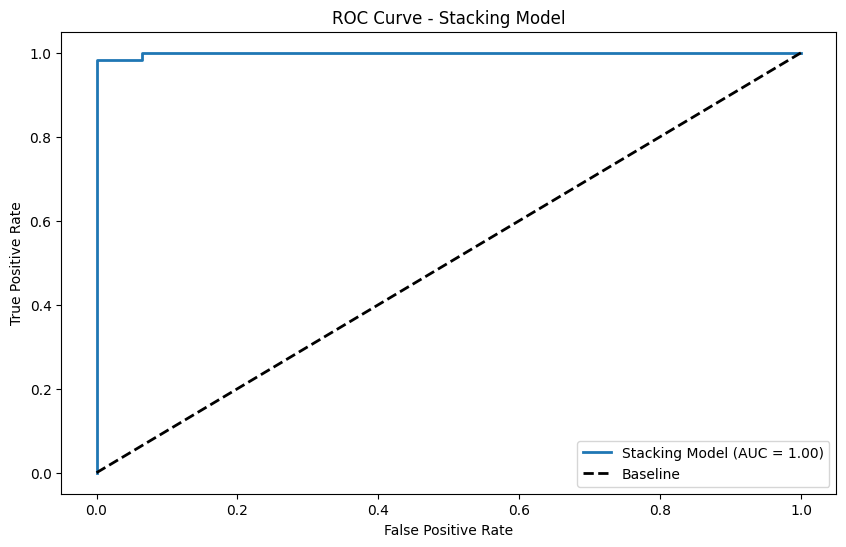

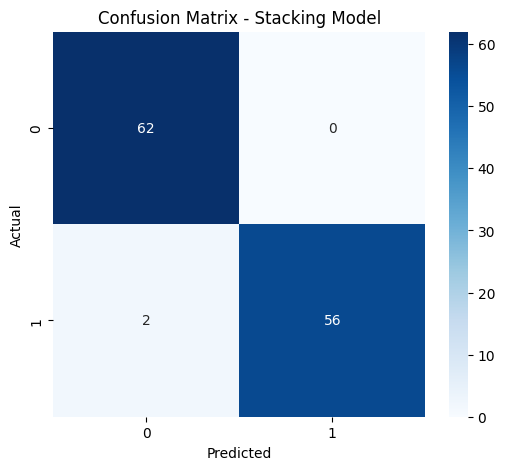

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from imblearn.combine import SMOTEENN

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/aqsaaries/pima-diabetese/pima-diabetes.csv')

# Ensure the correct target column is used
target_column = 'Outcome'
X = data.drop(columns=[target_column])
y = data[target_column]

# Standardizing numerical features BEFORE applying SMOTEENN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTEENN for handling class imbalance
smoteenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smoteenn.fit_resample(X_scaled, y)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Function for hyperparameter tuning
def hyperparameter_tuning():
    # Random Forest tuning
    param_grid_rf = {'n_estimators': [100, 300], 'max_depth': [None, 10, 20]}
    grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    best_rf = grid_rf.best_estimator_

    # XGBoost tuning
    param_grid_xgb = {'learning_rate': [0.01, 0.1, 0.2], 'n_estimators': [100, 300]}
    grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, cv=5, n_jobs=-1)
    grid_xgb.fit(X_train, y_train)
    best_xgb = grid_xgb.best_estimator_

    return best_rf, best_xgb

# Get best models
best_rf, best_xgb = hyperparameter_tuning()

# Calibrate SVM and KNN
svm_calibrated = CalibratedClassifierCV(SVC(kernel='rbf', probability=True), cv=5)
knn_calibrated = CalibratedClassifierCV(KNeighborsClassifier(n_neighbors=5), cv=5)

# Define base models
base_models = [
    ('Random Forest', best_rf),
    ('XGBoost', best_xgb),
    ('SVM', svm_calibrated),
    ('KNN', knn_calibrated)
]

# Define meta-model (MLPClassifier for better non-linearity)
meta_model = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)

# Create the stacking classifier
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)

# Train the stacking model
stacking_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_stack = stacking_clf.predict(X_test)
y_proba_stack = stacking_clf.predict_proba(X_test)[:, 1]

# Evaluate the stacking model
print("Stacking Model Performance:\n", classification_report(y_test, y_pred_stack))

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred_stack)
print(f"Stacking Model Accuracy: {accuracy:.4f}")

# Plot ROC Curve for Stacking Model
fpr, tpr, _ = roc_curve(y_test, y_proba_stack)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'Stacking Model (AUC = {roc_auc_score(y_test, y_proba_stack):.2f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Baseline")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Model')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**GRAPHS**

**Diabetese**

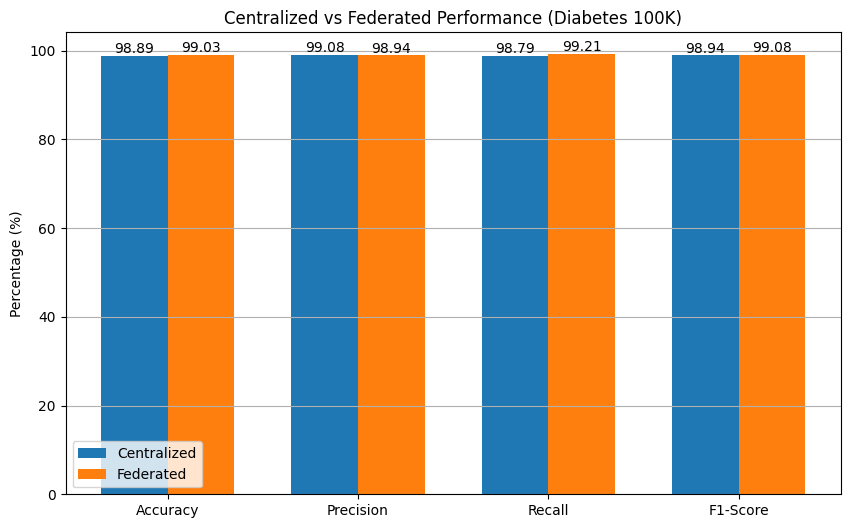

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# DATA (WITHOUT ROC-AUC)
# ============================
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

centralized = [98.89, 99.08, 98.79, 98.94]
federated   = [99.03, 98.94, 99.21, 99.08]

x = np.arange(len(metrics))
width = 0.35

# ============================
# BAR GRAPH
# ============================
plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, centralized, width, label="Centralized")
bars2 = plt.bar(x + width/2, federated, width, label="Federated")

plt.xticks(x, metrics)
plt.ylabel("Percentage (%)")
plt.title("Centralized vs Federated Performance (Diabetes 100K)")
plt.legend()
plt.grid(axis='y')

# value labels
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.2f}",
            ha='center', va='bottom'
        )

plt.show()

**Diabetes with clinical notes**

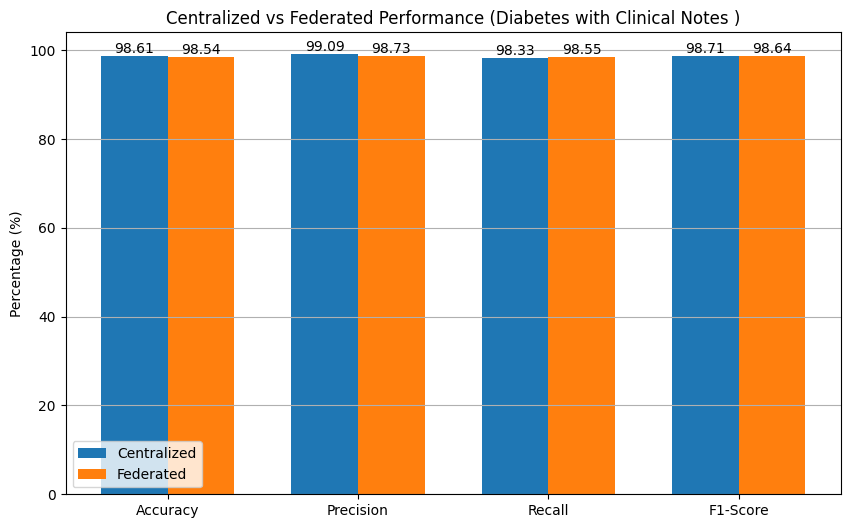

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# DATASET 2 VALUES (WITHOUT ROC-AUC)
# ============================
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

centralized = [98.61, 99.09, 98.33, 98.71]
federated   = [98.54, 98.73, 98.55, 98.64]

x = np.arange(len(metrics))
width = 0.35

# ============================
# BAR GRAPH
# ============================
plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, centralized, width, label="Centralized")
bars2 = plt.bar(x + width/2, federated, width, label="Federated")

plt.xticks(x, metrics)
plt.ylabel("Percentage (%)")
plt.title("Centralized vs Federated Performance (Diabetes with Clinical Notes )")
plt.legend()
plt.grid(axis='y')

# value labels
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.2f}",
            ha='center', va='bottom'
        )

plt.show()

**PIMA Diabetese**

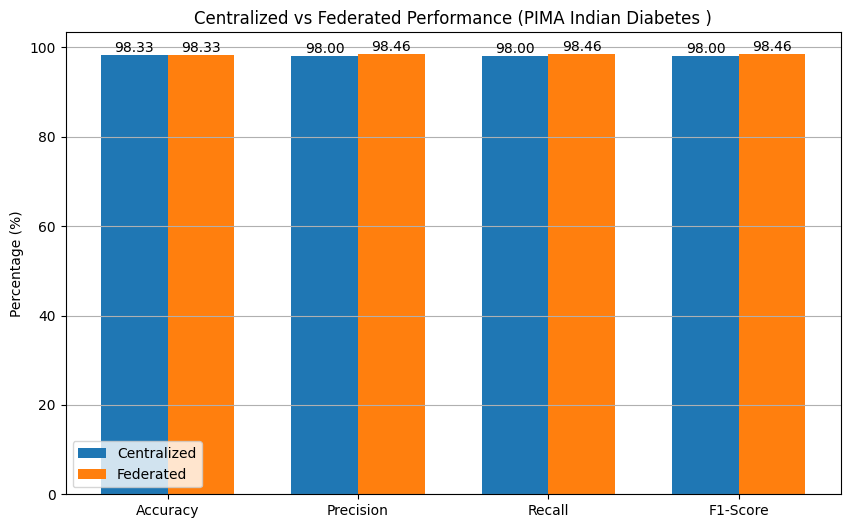

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# DATASET 3 VALUES (WITHOUT ROC-AUC)
# ============================
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

centralized = [98.33, 98.00, 98.00, 98.00]
federated   = [98.33, 98.46, 98.46, 98.46]

x = np.arange(len(metrics))
width = 0.35

# ============================
# BAR GRAPH
# ============================
plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, centralized, width, label="Centralized")
bars2 = plt.bar(x + width/2, federated, width, label="Federated")

plt.xticks(x, metrics)
plt.ylabel("Percentage (%)")
plt.title("Centralized vs Federated Performance (PIMA Indian Diabetes )")
plt.legend()
plt.grid(axis='y')

# value labels
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():.2f}",
            ha='center', va='bottom'
        )

plt.show()